In [1]:
# import libraries
import pandas as pd
import numpy as np


In [11]:
# load dataset
df = pd.read_csv('cancer_reg.csv',encoding = "latin1")

In [12]:
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


In [13]:
df.shape

(3047, 34)

In [15]:
df.columns.tolist()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [16]:
df.isnull().sum()

avgAnnCount                   0
avgDeathsPerYear              0
TARGET_deathRate              0
incidenceRate                 0
medIncome                     0
popEst2015                    0
povertyPercent                0
studyPerCap                   0
binnedInc                     0
MedianAge                     0
MedianAgeMale                 0
MedianAgeFemale               0
Geography                     0
AvgHouseholdSize              0
PercentMarried                0
PctNoHS18_24                  0
PctHS18_24                    0
PctSomeCol18_24            2285
PctBachDeg18_24               0
PctHS25_Over                  0
PctBachDeg25_Over             0
PctEmployed16_Over          152
PctUnemployed16_Over          0
PctPrivateCoverage            0
PctPrivateCoverageAlone     609
PctEmpPrivCoverage            0
PctPublicCoverage             0
PctPublicCoverageAlone        0
PctWhite                      0
PctBlack                      0
PctAsian                      0
PctOther

In [17]:
df.duplicated().sum()

np.int64(0)

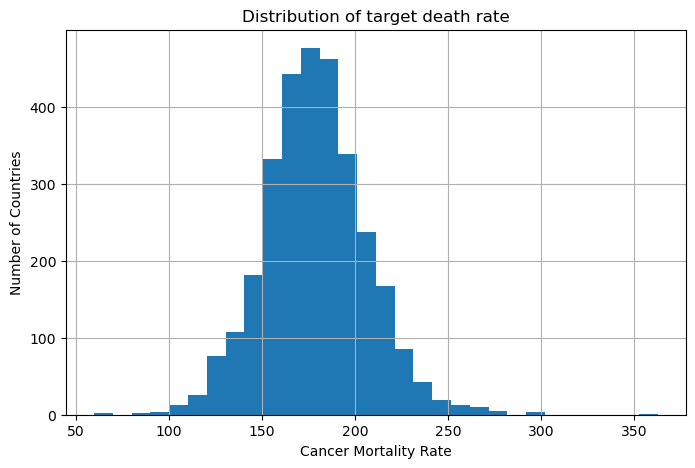

In [19]:
# distribution
import matplotlib.pyplot as plt

df["TARGET_deathRate"].hist(bins = 30, figsize=(8,5))

plt.xlabel("Cancer Mortality Rate")
plt.ylabel("Number of Countries")
plt.title("Distribution of target death rate")
plt.show()

In [20]:
# correlation analysis
#correlation with the target variable

correlation = df.corr(numeric_only=True)["TARGET_deathRate"].sort_values(ascending=False)

print(correlation)

TARGET_deathRate           1.000000
incidenceRate              0.449432
PctPublicCoverageAlone     0.449358
povertyPercent             0.429389
PctHS25_Over               0.404589
PctPublicCoverage          0.404572
PctUnemployed16_Over       0.378412
PctHS18_24                 0.261976
PctBlack                   0.257024
PctNoHS18_24               0.088463
MedianAgeFemale            0.012048
MedianAge                  0.004375
MedianAgeMale             -0.021929
studyPerCap               -0.022285
AvgHouseholdSize          -0.036905
BirthRate                 -0.087407
avgDeathsPerYear          -0.090715
popEst2015                -0.120073
avgAnnCount               -0.143532
PctWhite                  -0.177400
PctAsian                  -0.186331
PctSomeCol18_24           -0.188688
PctOtherRace              -0.189894
PercentMarried            -0.266820
PctEmpPrivCoverage        -0.267399
PctBachDeg18_24           -0.287817
PctMarriedHouseholds      -0.293325
PctPrivateCoverageAlone   -0

In [21]:
df["binnedInc"].unique()

df["Geography"].unique()

array(['Kitsap County, Washington', 'Kittitas County, Washington',
       'Klickitat County, Washington', ..., 'Ford County, Kansas',
       'Franklin County, Kansas', 'Geary County, Kansas'],
      shape=(3047,), dtype=object)

In [23]:
# create a copy for preprocessing

df_model = df.copy()

#drop categorical columns
df_model = df_model.drop(columns=["binnedInc","Geography"])

#fill missing numerical values with the median
for column in df_model.columns:
    if df_model[column].isnull().sum() > 0:
        df_model[column] = df_model[column].fillna(df_model[column].median())

# check missing values after preprocessing
print("Missing values after preprocessing:")
print(df_model.isnull().sum().sum())

df_model.shape

Missing values after preprocessing:
0


(3047, 32)

In [24]:
# Step 3: Feature selection and missing-value handling

# Remove categorical/identifier columns
df_model = df.drop(columns=["Geography", "binnedInc"]).copy()

# Separate target and features
X = df_model.drop(columns=["TARGET_deathRate"])
y = df_model["TARGET_deathRate"]

# Handle missing values using median
X = X.fillna(X.median())

# Check the result
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Features shape: (3047, 31)
Target shape: (3047,)
Missing values in X: 0
Missing values in y: 0


In [25]:
from sklearn.model_selection import train_test_split

#step4: Train - test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2437, 31)
X_test shape: (610, 31)
y_train shape: (2437,)
y_test shape: (610,)


In [27]:
from sklearn.linear_model import LinearRegression

#step5: multiple linear regression
linear_model = LinearRegression()

#train the model
linear_model.fit(X_train, y_train)

#make prediction
y_pred_linear = linear_model.predict(X_test)

print("number of prediction:", len(y_pred_linear))

number of prediction: 610


In [29]:
# Polynomial Regression Degree 2

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model  import LinearRegression

#polynomial features - Degree 2
poly2 = PolynomialFeatures(degree=2)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

#train polynomial regression model
poly_model2 = LinearRegression()
poly_model2.fit(X_train_poly2, y_train)

#predictions
y_pred_poly2 = poly_model2.predict(X_test_poly2)

print("number of predictions:", len(y_pred_poly2))

number of predictions: 610


In [30]:
# Polynomial features - Degree 3
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

# Train polynomial regression model
poly_model3 = LinearRegression()
poly_model3.fit(X_train_poly3, y_train)

# Predictions
y_pred_poly3 = poly_model3.predict(X_test_poly3)

print("Polynomial Regression Degree 3 trained successfully!")
print("Number of predictions:", len(y_pred_poly3))

Polynomial Regression Degree 3 trained successfully!
Number of predictions: 610


In [32]:

#Evaluate all 3 models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#linear regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

#polynomial regression degree 2
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

# Polynomial Regression Degree 3
mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
mse_poly3 = mean_squared_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mse_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)

# Display results
print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nPolynomial Regression Degree 2")
print("MAE :", mae_poly2)
print("MSE :", mse_poly2)
print("RMSE:", rmse_poly2)
print("R²  :", r2_poly2)

print("\nPolynomial Regression Degree 3")
print("MAE :", mae_poly3)
print("MSE :", mse_poly3)
print("RMSE:", rmse_poly3)
print("R²  :", r2_poly3)

Linear Regression
MAE : 15.089949801729977
MSE : 413.75611771899077
RMSE: 20.340995986406142
R²  : 0.4943372977171935

Polynomial Regression Degree 2
MAE : 15.791285184626604
MSE : 599.8922793077301
RMSE: 24.492698489707703
R²  : 0.2668551882552238

Polynomial Regression Degree 3
MAE : 46.25011385243187
MSE : 474242.5466961111
RMSE: 688.6527039779276
R²  : -578.5848264960382


In [33]:
#Conclusion: Multiple Linear Regression performed better than Polynomial Regression of degree 2 and degree 3 for predicting TARGET_deathRate on this dataset. The Linear Regression model achieved an MAE of 15.09, RMSE of 20.34, and R² of 0.4943. Polynomial Regression did not improve the prediction performance, while the degree-3 model showed very poor test-set performance.

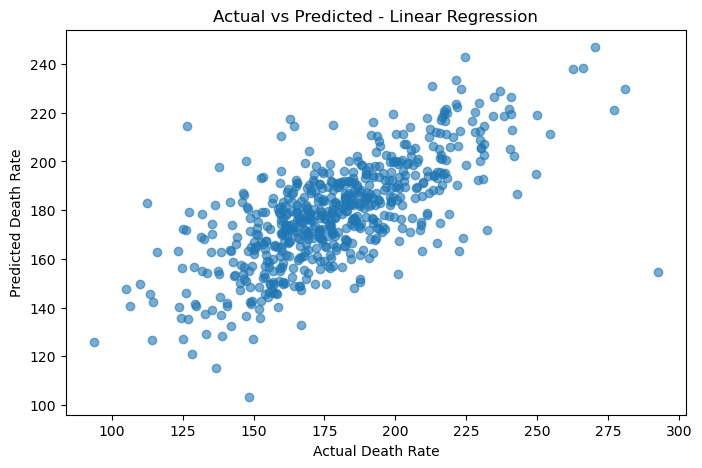

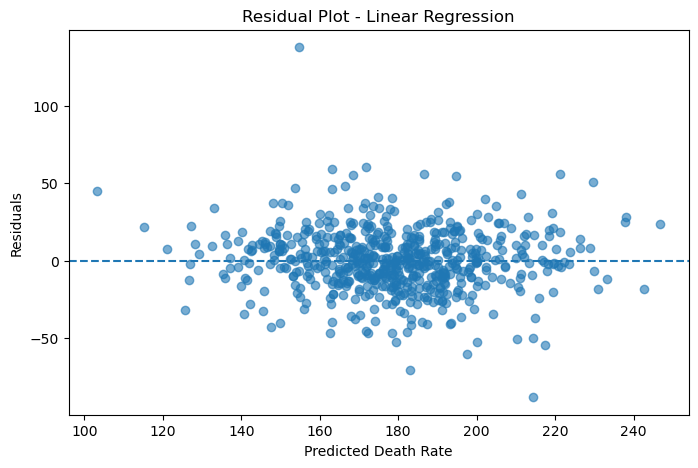

In [34]:
# Actual vs Predicted + Residual Plot

import matplotlib.pyplot as plt

# Actual vs Predicted - Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_linear, alpha=0.6)
plt.xlabel("Actual Death Rate")
plt.ylabel("Predicted Death Rate")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()


# Residual Plot - Linear Regression
residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_linear, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Death Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()